# Аудит качества данных: витрина ЕГАИС `doc_oper` против принятого потока `list_doc`

**Шаг 2 проектной работы — профилирование данных и метрики качества.**

Ракурс: аудит выполняет дата-инженер **контура приёмки ЕГАИС**. Мы проверяем не то, «правильно ли
организация отчиталась», а **не испортили ли мы сами** принятые от неё данные по пути от приёмки
до витрины, на которой строится контроль рынка.

| Слой | Таблица | Роль |
|---|---|---|
| Приёмка (сырой слой) | `public.list_doc` | Операции, принятые от организаций «как пришли» — **эталон** |
| Витрина контроля | `public.doc_oper` | Объект аудита: сверка деклараций, отраслевая статистика, основания для контрольных мероприятий |

Все числа ниже считаются **запросами к живой БД** `Project_DQ` в момент выполнения ноутбука,
ничего не захардкожено. SQL-исходники тех же проверок — `sql/01_profiling_queries.sql`.

In [1]:
import os
import warnings

import pandas as pd
import psycopg2

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50, "display.width", 200)

DB = dict(
    host=os.environ.get("DQ_PG_HOST", "localhost"),
    port=int(os.environ.get("DQ_PG_PORT", 5432)),
    user=os.environ.get("DQ_PG_USER", "postgres"),
    password=os.environ["DQ_PG_PASSWORD"],   # задать перед запуском, в файле пароля нет
    dbname=os.environ.get("DQ_PG_DBNAME", "Project_DQ"),
    connect_timeout=10,
)

conn = psycopg2.connect(**DB)

def q(sql, params=None):
    """Выполнить запрос и вернуть DataFrame."""
    return pd.read_sql_query(sql, conn, params=params)

print("Подключение к Project_DQ установлено:", q("select now() as ts").iloc[0, 0])

Подключение к Project_DQ установлено: 2026-08-30 16:02:00.797707+00:00


## 1. Объём и схема

Первое, что делает профилирование, — фиксирует масштаб и структуру. Уже здесь видно расхождение:
в витрине строк меньше, чем было принято, и колонок тоже меньше.

In [2]:
volumes = q("""
    -- Порядок строк задаём явно: без ORDER BY порядок веток UNION не гарантирован,
    -- а ниже мы обращаемся к ним по позиции.
    SELECT 1 AS ord, 'list_doc (приёмка)' AS table_name, count(*) AS row_count FROM public.list_doc
    UNION ALL
    SELECT 2, 'doc_oper (витрина)', count(*) FROM public.doc_oper
    ORDER BY ord
""").drop(columns="ord")
display(volumes)

src, tgt = int(volumes.row_count.iloc[0]), int(volumes.row_count.iloc[1])
print(f"Расхождение объёмов: {src - tgt:,} операций ({100 * (src - tgt) / src:.2f}% принятого потока)".replace(",", " "))

,table_name,row_count
0,list_doc (приёмка),1000000
1,doc_oper (витрина),900000


Расхождение объёмов: 100 000 операций (10.00% принятого потока)


In [3]:
schema = q("""
    SELECT table_name, ordinal_position AS pos, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'public' AND table_name IN ('list_doc', 'doc_oper')
    ORDER BY table_name, ordinal_position
""")
display(schema.pivot_table(index="pos", columns="table_name",
                           values="column_name", aggfunc="first").fillna("—"))

table_name,doc_oper,list_doc
pos,,
1,id,sid
2,org_id,client_id
3,operation,operation
4,date_operation,oper_date
5,type_doc,doc_type
6,cod_alco,doc_id
7,qua,product_id
8,doc_2,quantity
9,doc_1,form_b


**Несоответствие схемы.** Принятый поток шире витрины: 12 колонок против 9. При загрузке
происходит переименование (`sid→id`, `client_id→org_id`, `oper_date→date_operation`,
`doc_type→type_doc`, `product_id→cod_alco`, `quantity→qua`, `form_b→doc_2`, `form_a→doc_1`),
три атрибута (`doc_id`, `bottling_date`, `wbpid`) не переносятся вовсе, а точность количества
сужается с 4 знаков до 3. Ни одно из этих преобразований нигде не закреплено контрактом — оно
живёт только в коде загрузки. Именно поэтому дефект вроде потерянного ведущего нуля некому
поймать: его не с чем сверить.

## 2. Целостность эталона

Прежде чем обвинять данные, проверяем сам эталон. Если источник грязный, всё расследование
повиснет в воздухе: непонятно, кто виноват — организации или мы.

In [4]:
source_integrity = q(r"""
    SELECT
        count(*)                                                          AS rows_total,
        count(DISTINCT sid)                                               AS sid_distinct,
        count(*) FILTER (WHERE client_id IS NULL OR operation IS NULL
                            OR oper_date IS NULL OR doc_type IS NULL
                            OR product_id IS NULL OR quantity IS NULL)    AS rows_with_nulls,
        count(*) FILTER (WHERE client_id ~ '^0\\d{7}$')                    AS client_id_valid,
        count(*) FILTER (WHERE bottling_date IS NOT NULL)                 AS bottling_date_filled,
        count(*) FILTER (WHERE wbpid IS NOT NULL)                         AS wbpid_filled
    FROM public.list_doc
""")
display(source_integrity.T.rename(columns={0: "значение"}))

s = source_integrity.iloc[0]
print("Ключ уникален:            ", s.rows_total == s.sid_distinct)
print("Обязательные поля пусты:  ", int(s.rows_with_nulls))
print(f"client_id формата ^0\\d{{7}}$: {100 * s.client_id_valid / s.rows_total:.2f}%")
print("bottling_date / wbpid заполнены:", int(s.bottling_date_filled), "/", int(s.wbpid_filled))

,значение
rows_total,1000000
sid_distinct,1000000
rows_with_nulls,0
client_id_valid,0
bottling_date_filled,0
wbpid_filled,0


Ключ уникален:             True
Обязательные поля пусты:   0
client_id формата ^0\d{7}$: 0.00%
bottling_date / wbpid заполнены: 0 / 0


**Вывод: принятый источник целостен.** Ключ уникален, обязательные поля заполнены, код
организации на 100% соответствует формату «8 цифр с ведущим нулём». Организации отчитались
корректно — значит всё, что найдено дальше, возникло **внутри нашего контура**.

Единственный дефект самого источника — `bottling_date` и `wbpid` не заполнены **ни разу**:
это разрыв полноты на уровне схемы, из-за которого партию невозможно проследить.

## 3. Структура документов: партии и перемещения

Прежде чем считать метрики, надо понять, чем вообще являются справки А и Б — иначе половина
проверок посчитается не про то.

- **Справка А** (`form_a` / `doc_1`) сопровождает **партию** продукции от производства или импорта
  до конечной продажи. Партия проходит через нескольких участников рынка, поэтому один номер
  закономерно повторяется во множестве операций.
- **Справка Б** (`form_b` / `doc_2`) фиксирует **перемещение** партии между участниками и
  принадлежит ровно одной справке А. Тоже покрывает несколько операций: приход у получателя,
  списание у отправителя.
- **Код продукции** — атрибут партии: в рамках одной справки А товар один и тот же.

Отсюда следствие, определяющее набор правил: проверять **уникальность** номеров справок нельзя,
это дало бы ложное срабатывание почти на всех строках. Проверять надо **структуру**.

In [5]:
hierarchy = q("""
    SELECT
        count(*)                                                        AS operations,
        count(DISTINCT form_a)                                          AS spravka_a,
        count(DISTINCT form_b)                                          AS spravka_b,
        count(DISTINCT product_id)                                      AS products,
        round(count(*)::numeric / count(DISTINCT form_a), 1)            AS ops_per_batch,
        round(count(*)::numeric / count(DISTINCT form_b), 1)            AS ops_per_move,
        round(count(DISTINCT form_b)::numeric / count(DISTINCT form_a), 1) AS moves_per_batch
    FROM public.list_doc
""")
display(hierarchy.T.rename(columns={0: "значение"}))

,значение
operations,1000000.0
spravka_a,10000.0
spravka_b,200000.0
products,10000.0
ops_per_batch,100.0
ops_per_move,5.0
moves_per_batch,20.0


In [6]:
structure = q("""
    SELECT
        -- DQ-12: справка Б обязана принадлежать ровно одной справке А
        (SELECT count(*) FROM (
            SELECT doc_2 FROM public.doc_oper GROUP BY doc_2 HAVING count(DISTINCT doc_1) > 1
         ) x)                                                       AS moves_in_two_batches,
        -- DQ-13: в рамках справки А один код продукции
        (SELECT count(*) FROM (
            SELECT doc_1 FROM public.doc_oper GROUP BY doc_1 HAVING count(DISTINCT cod_alco) > 1
         ) x)                                                       AS batches_with_many_products,
        -- сколько документов вообще дошло до витрины
        (SELECT count(DISTINCT doc_1) FROM public.doc_oper)         AS batches_in_mart,
        (SELECT count(DISTINCT doc_2) FROM public.doc_oper)         AS moves_in_mart
""")
display(structure.T.rename(columns={0: "значение"}))

,значение
moves_in_two_batches,0
batches_with_many_products,0
batches_in_mart,10000
moves_in_mart,199997


In [7]:
batch_impact = q("""
    WITH per_batch AS (
        SELECT l.form_a,
               count(*)                              AS ops,
               count(*) FILTER (WHERE o.id IS NULL)  AS lost
        FROM public.list_doc l
        LEFT JOIN public.doc_oper o ON o.id = l.sid
        GROUP BY l.form_a
    )
    SELECT count(*)                                  AS batches_total,
           count(*) FILTER (WHERE lost > 0)          AS batches_with_losses,
           count(*) FILTER (WHERE lost = ops)        AS batches_lost_fully,
           round(avg(lost), 1)                       AS avg_lost_per_batch,
           max(lost)                                 AS max_lost_per_batch
    FROM per_batch
""")
display(batch_impact)

b = batch_impact.iloc[0]
print(f"Партий задето потерями: {int(b.batches_with_losses):,} из {int(b.batches_total):,}".replace(",", " "))
print(f"Потеряно целиком: {int(b.batches_lost_fully)} — то есть ни одной")
print(f"В среднем теряется {b.avg_lost_per_batch} операций из 100 на партию (максимум {int(b.max_lost_per_batch)})")

,batches_total,batches_with_losses,batches_lost_fully,avg_lost_per_batch,max_lost_per_batch
0,10000,10000,0,10.0,23


Партий задето потерями: 10 000 из 10 000
Потеряно целиком: 0 — то есть ни одной
В среднем теряется 10.0 операций из 100 на партию (максимум 23)


Структура документов целая: ни одно перемещение не приписано двум партиям, ни одна партия не
содержит разных товаров. Зато видно другое — **потери задели все 10 000 партий**: в среднем
10 операций из 100 на партию. Ни одна партия не потеряна целиком, но и ни одна не представлена
в контуре контроля полностью. Для прослеживаемости это хуже, чем потеря отдельных партий
целиком: дефект незаметен при выборочной проверке, потому что каждая партия «вроде бы есть».

Три справки Б потеряны полностью (199 997 в витрине против 200 000 в приёмке) — все операции
этих перемещений оказались в числе непогруженных.

## 4. Метрики качества витрины

Считаем классические измерения качества (dimensions) по витрине. Каждая метрика ниже
соответствует правилу из реестра `docs/Реестр правил и метрик.md`.

In [8]:
completeness = q("""
    SELECT
        count(*) AS total_rows,
        round(100.0 * count(*) FILTER (WHERE org_id         IS NULL) / count(*), 3) AS null_pct_org_id,
        round(100.0 * count(*) FILTER (WHERE operation      IS NULL) / count(*), 3) AS null_pct_operation,
        round(100.0 * count(*) FILTER (WHERE date_operation IS NULL) / count(*), 3) AS null_pct_date_operation,
        round(100.0 * count(*) FILTER (WHERE type_doc       IS NULL) / count(*), 3) AS null_pct_type_doc,
        round(100.0 * count(*) FILTER (WHERE cod_alco       IS NULL) / count(*), 3) AS null_pct_cod_alco,
        round(100.0 * count(*) FILTER (WHERE qua            IS NULL) / count(*), 3) AS null_pct_qua,
        round(100.0 * count(*) FILTER (WHERE doc_1          IS NULL) / count(*), 3) AS null_pct_doc_1,
        round(100.0 * count(*) FILTER (WHERE doc_2          IS NULL) / count(*), 3) AS null_pct_doc_2
    FROM public.doc_oper
""")
display(completeness.T.rename(columns={0: "значение"}))

,значение
total_rows,900000.0
null_pct_org_id,0.0
null_pct_operation,0.0
null_pct_date_operation,0.0
null_pct_type_doc,0.0
null_pct_cod_alco,0.0
null_pct_qua,0.0
null_pct_doc_1,0.0
null_pct_doc_2,0.0


In [9]:
metrics = q(r"""
    WITH load_completeness AS (
        SELECT round(100.0 * (SELECT count(*) FROM public.doc_oper)
                            / (SELECT count(*) FROM public.list_doc), 2) AS v,
               (SELECT count(*) FROM public.list_doc l
                LEFT JOIN public.doc_oper d ON d.id = l.sid
                WHERE d.id IS NULL) AS bad
    ),
    uniqueness AS (
        SELECT round(100.0 * count(DISTINCT id) / count(*), 2) AS v,
               count(*) - count(DISTINCT id) AS bad
        FROM public.doc_oper
    ),
    integrity AS (
        SELECT round(100.0 * count(*) FILTER (WHERE l.sid IS NOT NULL) / count(*), 2) AS v,
               count(*) FILTER (WHERE l.sid IS NULL) AS bad
        FROM public.doc_oper d
        LEFT JOIN public.list_doc l ON l.sid = d.id
    ),
    accuracy AS (
        SELECT round(100.0 * count(*) FILTER (WHERE d.org_id = l.client_id) / count(*), 2) AS v,
               count(*) FILTER (WHERE d.org_id <> l.client_id) AS bad
        FROM public.doc_oper d JOIN public.list_doc l ON l.sid = d.id
    ),
    validity_org AS (
        SELECT round(100.0 * count(*) FILTER (WHERE org_id ~ '^0\\d{7}$') / count(*), 2) AS v,
               count(*) FILTER (WHERE org_id !~ '^0\\d{7}$') AS bad
        FROM public.doc_oper
    ),
    validity_type AS (
        SELECT round(100.0 * count(*) FILTER (WHERE type_doc IN ('chek','spis')) / count(*), 2) AS v,
               count(*) FILTER (WHERE type_doc NOT IN ('chek','spis')) AS bad
        FROM public.doc_oper
    ),
    consistency AS (
        SELECT round(100.0 * count(*) FILTER (
                   WHERE (type_doc='chek' AND qua>0) OR (type_doc='spis' AND qua<0)) / count(*), 2) AS v,
               count(*) FILTER (
                   WHERE NOT ((type_doc='chek' AND qua>0) OR (type_doc='spis' AND qua<0))) AS bad
        FROM public.doc_oper
    ),
    validity_forms AS (
        SELECT round(100.0 * count(*) FILTER (
                   WHERE doc_1 ~ '^1_\\d{10}$' AND doc_2 ~ '^2_\\d{10}$') / count(*), 2) AS v,
               count(*) FILTER (
                   WHERE NOT (doc_1 ~ '^1_\\d{10}$' AND doc_2 ~ '^2_\\d{10}$')) AS bad
        FROM public.doc_oper
    ),
    timeliness AS (
        SELECT round(100.0 * count(*) FILTER (WHERE date_operation <= now()) / count(*), 2) AS v,
               count(*) FILTER (WHERE date_operation > now()) AS bad
        FROM public.doc_oper
    )
    SELECT 'Completeness (полнота загрузки)' AS metric, 'DQ-02' AS rule, v AS pass_rate_pct, bad AS failed_rows FROM load_completeness
    UNION ALL SELECT 'Uniqueness (ключ витрины)',        'DQ-05', v, bad FROM uniqueness
    UNION ALL SELECT 'Integrity (строки без источника)', 'DQ-11', v, bad FROM integrity
    UNION ALL SELECT 'Accuracy (org_id vs client_id)',   'DQ-04', v, bad FROM accuracy
    UNION ALL SELECT 'Validity (формат org_id)',         'DQ-03', v, bad FROM validity_org
    UNION ALL SELECT 'Validity (тип документа)',         'DQ-06', v, bad FROM validity_type
    UNION ALL SELECT 'Consistency (знак количества)',    'DQ-07', v, bad FROM consistency
    UNION ALL SELECT 'Validity (Формы А/Б)',             'DQ-10', v, bad FROM validity_forms
    UNION ALL SELECT 'Timeliness (нет дат из будущего)', 'DQ-08', v, bad FROM timeliness
""")
metrics["вердикт"] = metrics.pass_rate_pct.map(lambda x: "OK" if x >= 99 else "ПРОБЛЕМА")
display(metrics)

,metric,rule,pass_rate_pct,failed_rows,вердикт
0,Completeness (полнота загрузки),DQ-02,90.0,100000,ПРОБЛЕМА
1,Validity (тип документа),DQ-06,100.0,0,OK
2,Validity (формат org_id),DQ-03,0.0,900000,ПРОБЛЕМА
3,Timeliness (нет дат из будущего),DQ-08,100.0,0,OK
4,Validity (Формы А/Б),DQ-10,0.0,900000,ПРОБЛЕМА
5,Accuracy (org_id vs client_id),DQ-04,90.0,90000,ПРОБЛЕМА
6,Consistency (знак количества),DQ-07,100.0,0,OK
7,Integrity (строки без источника),DQ-11,100.0,0,OK
8,Uniqueness (ключ витрины),DQ-05,100.0,0,OK


Две метрики из девяти красные, и обе — про сверку с источником: **полнота загрузки** и
**точность кода организации**. Всё, что можно проверить внутри самой витрины (уникальность,
типы документов, знаки количеств, форматы деклараций), выглядит идеально. Это ключевое
наблюдение всего аудита: **однотабличные проверки не увидели бы ни одного из двух главных
дефектов** — их видно только в сравнении с принятым потоком.

## 5. Природа дефекта кода организации

Смотрим, чем именно испорчены 90 000 значений `org_id`.

In [10]:
lengths = q("""
    SELECT length(org_id) AS org_id_len, count(*) AS rows,
           round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct
    FROM public.doc_oper GROUP BY 1 ORDER BY 1
""")
display(lengths)

recoverable = q("""
    SELECT count(*) AS damaged,
           count(*) FILTER (WHERE '0' || d.org_id = l.client_id) AS restored_by_leading_zero
    FROM public.doc_oper d JOIN public.list_doc l ON l.sid = d.id
    WHERE d.org_id <> l.client_id
""")
display(recoverable)

r = recoverable.iloc[0]
print(f"Восстановимость возвратом ведущего нуля: {r.restored_by_leading_zero:,} из {r.damaged:,} "
      f"({100 * r.restored_by_leading_zero / r.damaged:.2f}%)".replace(",", " "))

,org_id_len,rows,pct
0,7,90000,10.0
1,8,810000,90.0


,damaged,restored_by_leading_zero
0,90000,90000


Восстановимость возвратом ведущего нуля: 90 000 из 90 000 (100.00%)


Испорченные значения не «случайно разные» — они все ровно на один символ короче, и **все до
единого** восстанавливаются возвратом ведущего нуля. Это подпись конкретного механизма:
код организации где-то в загрузке был приведён к числу и обратно к строке. Для числа ведущий
ноль незначащ, для кода организации — значащ.

## 6. Проверка гипотез: баг загрузки или ручное вмешательство?

Источник цел, витрина испорчена двумя способами. Разбираемся, что именно произошло.

Начинаем с признака, который решает вопрос сразу: **какая доля кодов испорчена**. Системный баг
приведения типа внутри ETL применяется к каждой строке потока — он испортил бы 100% кодов.
Если испорчена лишь часть, значит преобразование применялось к выделенному подмножеству строк,
то есть выполнялось отдельно от штатной загрузки.

In [11]:
damage_share = q(r"""
    SELECT count(*)                                              AS mart_rows,
           count(*) FILTER (WHERE org_id !~ '^0\d{7}$')          AS damaged_rows,
           round(100.0 * count(*) FILTER (WHERE org_id !~ '^0\d{7}$') / count(*), 2) AS damaged_pct
    FROM public.doc_oper
""")
display(damage_share)

d = damage_share.iloc[0]
print(f"Испорчено {d.damaged_pct}% кодов — не 100%.")
print("Значит это не баг преобразования внутри загрузки: он задел бы весь поток.")

,mart_rows,damaged_rows,damaged_pct
0,900000,90000,10.0


Испорчено 10.0% кодов — не 100%.
Значит это не баг преобразования внутри загрузки: он задел бы весь поток.


Испорчена ровно каждая десятая строка. Баг в коде загрузки так не умеет —
он либо портит все коды, либо ни одного. Дальше выясняем, что представляет собой это подмножество.

In [12]:
orphans_dupes = q("""
    SELECT
        (SELECT count(*) FROM public.doc_oper d
         LEFT JOIN public.list_doc l ON l.sid = d.id
         WHERE l.sid IS NULL)                                       AS orphan_rows,
        (SELECT count(*) - count(DISTINCT id) FROM public.doc_oper) AS duplicate_ids
""")
display(orphans_dupes)

,orphan_rows,duplicate_ids
0,0,0


In [13]:
by_day = q("""
    WITH lost AS (
        SELECT date_trunc('day', l.oper_date)::date AS d, count(*) AS lost_rows
        FROM public.list_doc l
        LEFT JOIN public.doc_oper o ON o.id = l.sid
        WHERE o.id IS NULL
        GROUP BY 1
    ),
    damaged AS (
        SELECT date_trunc('day', d.date_operation)::date AS d, count(*) AS damaged_rows
        FROM public.doc_oper d JOIN public.list_doc l ON l.sid = d.id
        WHERE d.org_id <> l.client_id
        GROUP BY 1
    )
    SELECT coalesce(lost.d, damaged.d) AS day,
           coalesce(lost_rows, 0) AS lost_rows,
           coalesce(damaged_rows, 0) AS damaged_rows
    FROM lost FULL JOIN damaged ON lost.d = damaged.d
    ORDER BY 1
""")
print(f"Дней в потоке: {len(by_day)}  ({by_day.day.min()} … {by_day.day.max()})")
print(f"Потери за день:     min {by_day.lost_rows.min()}, max {by_day.lost_rows.max()}, "
      f"дней без потерь: {(by_day.lost_rows == 0).sum()}")
print(f"Искажения за день:  min {by_day.damaged_rows.min()}, max {by_day.damaged_rows.max()}, "
      f"дней без искажений: {(by_day.damaged_rows == 0).sum()}")
display(by_day.head())

Дней в потоке: 113  (2026-05-01 … 2026-08-21)
Потери за день:     min 813, max 959, дней без потерь: 0
Искажения за день:  min 732, max 870, дней без искажений: 0


,day,lost_rows,damaged_rows
0,2026-05-01,940,810
1,2026-05-02,895,781
2,2026-05-03,844,836
3,2026-05-04,862,802
4,2026-05-05,903,756


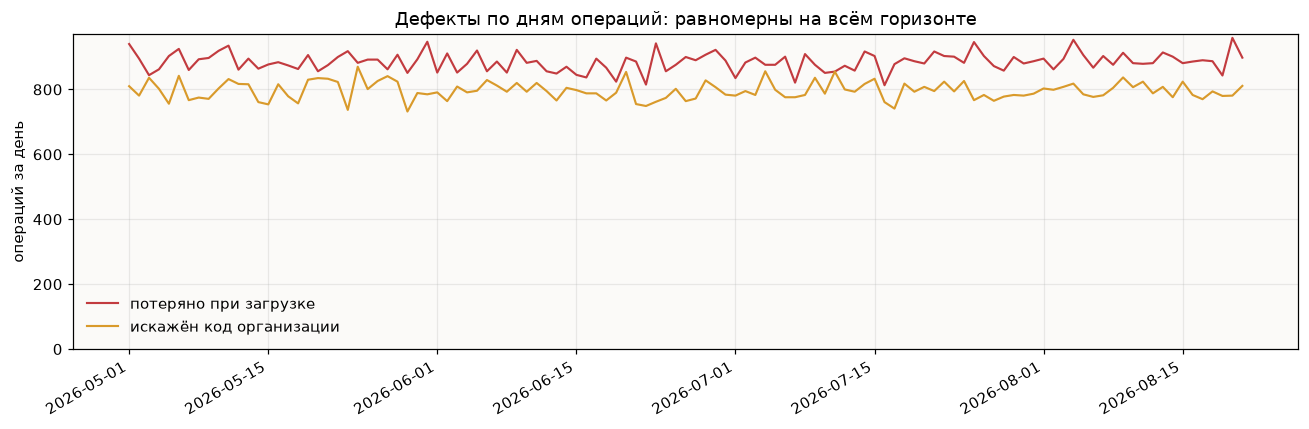

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.facecolor": "#fbfaf8", "font.size": 10})

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_day.day, by_day.lost_rows, lw=1.4, color="#c23b3f", label="потеряно при загрузке")
ax.plot(by_day.day, by_day.damaged_rows, lw=1.4, color="#d99a2b", label="искажён код организации")
ax.set_title("Дефекты по дням операций: равномерны на всём горизонте", fontsize=12)
ax.set_ylabel("операций за день")
ax.set_ylim(0)
ax.grid(alpha=.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

График — главный аргумент расследования. Ручное вмешательство дало бы всплеск: один день,
одну пачку, один диапазон ключей. Здесь обе линии идут ровной полосой по **всем** дням потока
без единого провала — так выглядит систематическое преобразование, применённое ко всему потоку,
а не точечная правка.

In [15]:
selectivity = q("""
    WITH joined AS (
        SELECT l.client_id, o.id AS loaded_id, o.org_id
        FROM public.list_doc l
        LEFT JOIN public.doc_oper o ON o.id = l.sid
    )
    SELECT
        count(DISTINCT client_id)                                              AS orgs_total,
        count(DISTINCT client_id) FILTER (WHERE loaded_id IS NULL)             AS orgs_with_losses,
        count(DISTINCT client_id) FILTER (WHERE org_id IS NOT NULL
                                            AND org_id <> client_id)           AS orgs_with_damage
    FROM joined
""")
display(selectivity)

by_type = q("""
    -- Анти-джойн вместо коррелированного NOT EXISTS: в doc_oper нет индекса по id,
    -- поэтому подзапрос внутри FILTER считался бы построчно.
    SELECT l.doc_type,
           count(*) AS accepted,
           count(*) FILTER (WHERE o.id IS NULL) AS lost
    FROM public.list_doc l
    LEFT JOIN public.doc_oper o ON o.id = l.sid
    GROUP BY 1 ORDER BY 1
""")
by_type["lost_pct"] = (100 * by_type.lost / by_type.accepted).round(2)
display(by_type)

,orgs_total,orgs_with_losses,orgs_with_damage
0,5000,5000,5000


,doc_type,accepted,lost,lost_pct
0,chek,500000,50059,10.01
1,spis,500000,49941,9.99


In [16]:
neighbours = q("""
    SELECT count(*) AS damaged_rows,
           count(*) FILTER (
               WHERE d.qua = l.quantity
                 AND d.date_operation = l.oper_date
                 AND d.cod_alco = l.product_id
                 AND d.doc_1 = l.form_a
                 AND d.doc_2 = l.form_b) AS neighbours_intact
    FROM public.doc_oper d JOIN public.list_doc l ON l.sid = d.id
    WHERE d.org_id <> l.client_id
""")
display(neighbours)

n = neighbours.iloc[0]
print(f"У {n.neighbours_intact:,} из {n.damaged_rows:,} испорченных строк все остальные поля "
      f"совпадают с источником 1:1".replace(",", " "))

,damaged_rows,neighbours_intact
0,90000,90000


У 90 000 из 90 000 испорченных строк все остальные поля совпадают с источником 1:1


### Вердикт: это была ручная довставка данных

| Признак | Факт на данных | Что означает |
|---|---|---|
| Доля искажённых кодов | **10%**, а не 100% | преобразование применялось к подмножеству → не баг ETL |
| Строки-«сироты» | 0 | вставляли **реальные операции из приёмки**, а не выдуманные записи |
| Дубли ключа | 0 | вставляли только то, чего в витрине не было |
| Соседние поля | у всех 90 000 совпадают с источником 1:1 | данные брали из приёмки, испортился ровно один атрибут |
| Характер искажения | 90 000 из 90 000 восстанавливаются возвратом нуля | один механизм на всём подмножестве — числовое приведение |
| Потери + искажения по дням | стабильно ≈1 681 операция в день | исходная «дыра» загрузки была равномерной, ≈190 000 операций |

**Реконструкция событий.**

1. Загрузка потеряла ≈190 000 операций, равномерно по всему периоду.
2. Дыру заметили частично и **вручную довосстановили 90 000 операций**: выгрузили из приёмки,
   провели через промежуточный инструмент, вставили в витрину.
3. В этом ручном цикле код организации прошёл числовое приведение и потерял ведущий ноль.
4. Оставшиеся 100 000 операций не восстановили — их не заметили.
5. Ни вставку, ни её последствия никто не зафиксировал: журнала изменений витрины нет.

**Проблема с кодом организации — не причина, а следствие:** она возникла при попытке починить
потерю данных, и на неё не обратили внимания.

**Почему это не поймали раньше.** Правило DQ-11 (строки без источника) такую вставку не ловит и
сегодня зелёное: вставляли реальные операции, у каждой есть пара в `list_doc`. Сторож
происхождения проверяет, что запись *была* в приёмке, но не что она попала в витрину штатным
путём и без искажений. Дефект по существу данных ловит другое правило — **баланс перемещения**
(следующий раздел).

**Чего данные всё равно не доказывают.** Они показывают *что* произошло, но не *кто и когда* это
сделал и была ли операция согласована. Для этого нужен журнал изменений витрины, которого нет.

## 7. Баланс перемещения: правило, которым разбирают инциденты

Справка Б сопровождает поставку партии участнику рынка: он приходует товар (`chek`, +) и
списывает его в продажу (`spis`, −). **Списать больше, чем получено, невозможно** — значит сумма
количеств в разрезе «организация × справка Б» не может быть отрицательной. Это правило DQ-14.

In [17]:
balance = q("""
    WITH src AS (
        SELECT client_id, form_b, sum(quantity) AS balance
        FROM public.list_doc GROUP BY 1, 2
    ),
    mart AS (
        SELECT org_id, doc_2, sum(qua) AS balance
        FROM public.doc_oper GROUP BY 1, 2
    )
    SELECT 'приёмка (list_doc)' AS layer,
           count(*)                                    AS pairs,
           count(*) FILTER (WHERE balance < 0)         AS negative,
           count(*) FILTER (WHERE balance = 0)         AS zero,
           round(100.0 * count(*) FILTER (WHERE balance >= 0) / count(*), 2) AS pass_rate_pct
    FROM src
    UNION ALL
    SELECT 'витрина (doc_oper)', count(*),
           count(*) FILTER (WHERE balance < 0),
           count(*) FILTER (WHERE balance = 0),
           round(100.0 * count(*) FILTER (WHERE balance >= 0) / count(*), 2)
    FROM mart
""")
display(balance)

,layer,pairs,negative,zero,pass_rate_pct
0,витрина (doc_oper),274995,96309,55816,64.98
1,приёмка (list_doc),200000,0,160000,100.00


В принятом потоке нарушений нет вовсе: 200 000 пар, отрицательных ноль, у 80%
баланс ровно нулевой (партия реализована полностью). В витрине пар оказывается **больше**, чем в
приёмке, — искажение кода расщепляет пару надвое, и часть операций перемещения уезжает под
7-значный код.

Дальше — самое ценное для разбора инцидента: по характеру расхождения видно, **каким именно**
из двух дефектов задета конкретная пара.

In [18]:
diagnosis = q(r"""
    WITH g AS MATERIALIZED (
        SELECT org_id, doc_2, sum(qua) AS balance
        FROM public.doc_oper GROUP BY org_id, doc_2
    )
    SELECT count(*)                                        AS negative_pairs_8digit,
           count(*) FILTER (WHERE m.balance IS NOT NULL)   AS with_mirror_7digit,
           count(*) FILTER (WHERE m.balance IS NULL)       AS without_mirror
    FROM g v
    -- зеркало = та же справка Б под кодом без ведущего нуля: часть операций
    -- перемещения уехала туда при ручной вставке
    LEFT JOIN g m ON m.doc_2 = v.doc_2
                 AND m.org_id = substring(v.org_id from 2)
    WHERE v.balance < 0 AND v.org_id ~ '^0\d{7}$'
""")
display(diagnosis)

x = diagnosis.iloc[0]
print(f"Следы ручной вставки (есть зеркало под 7-значным кодом): {x.with_mirror_7digit:,}".replace(",", " "))
print(f"Потери при загрузке (зеркала нет):                       {x.without_mirror:,}".replace(",", " "))

,negative_pairs_8digit,with_mirror_7digit,without_mirror
0,59222,34195,25027


Следы ручной вставки (есть зеркало под 7-значным кодом): 34 195
Потери при загрузке (зеркала нет):                       25 027


Правило не просто краснеет — оно **сортирует проблему по причинам**:

- пара с отрицательным балансом, у которой есть зеркальная пара под 7-значным кодом с
  положительным балансом, — след ручной вставки: операции перемещения разъехались по двум кодам;
- пара без зеркала — операции просто не доехали при загрузке.

Поэтому разбор заявки от организации начинается не с нуля: по одному запросу видно, что именно
случилось с её поставкой и какое из двух исправлений нужно.

## 8. История мониторинга

Правила из реестра уже работают как ежедневный пайплайн (Шаг 4). Смотрим накопленную историю
прогонов — это и есть observability-часть проекта.

In [19]:
runs = q("""
    SELECT run_id, triggered_by, run_started_at, total_rules, passed_rules, failed_rules, overall_status
    FROM public.dq_run_history ORDER BY run_id DESC LIMIT 10
""")
display(runs)

last_run = q("""
    SELECT rule_id, entity, dimension, pass_rate_pct, threshold_pct, status
    FROM public.dq_check_results
    WHERE run_id = (SELECT max(run_id) FROM public.dq_run_history)
    ORDER BY rule_id
""")
display(last_run)

,run_id,triggered_by,run_started_at,total_rules,passed_rules,failed_rules,overall_status
0,30,manual,2026-08-30 18:55:43.850464,14,10,4,FAIL
1,29,manual,2026-08-30 18:28:52.442437,13,10,3,FAIL
2,28,airflow,2026-08-30 17:41:32.130392,11,8,3,FAIL
3,27,airflow,2026-08-30 16:48:46.280406,11,8,3,FAIL
4,26,airflow,2026-08-29 09:00:01.789371,11,8,3,FAIL
5,25,airflow,2026-08-28 09:00:01.972616,11,8,3,FAIL
6,24,airflow,2026-08-27 09:00:02.089756,11,8,3,FAIL
7,23,airflow,2026-08-26 09:00:02.177043,11,8,3,FAIL
8,22,airflow,2026-08-25 09:00:01.887487,11,8,3,FAIL
9,21,airflow,2026-08-24 09:00:02.455349,11,8,3,FAIL


,rule_id,entity,dimension,pass_rate_pct,threshold_pct,status
0,DQ-01,Операция,Completeness,100.00,100.0,PASS
1,DQ-02,Операция,Completeness (загрузка),90.00,99.0,FAIL
2,DQ-03,Организация,Validity,90.00,99.0,FAIL
3,DQ-04,Организация,Accuracy,90.00,99.0,FAIL
4,DQ-05,Операция,Uniqueness,100.00,100.0,PASS
5,DQ-06,Документ учёта,Validity,100.00,100.0,PASS
6,DQ-07,Операция,Consistency,100.00,100.0,PASS
7,DQ-08,Операция,Timeliness,100.00,100.0,PASS
8,DQ-09,Товар,Validity,100.00,99.0,PASS
9,DQ-10,Форма А / Форма Б,Validity,100.00,99.0,PASS


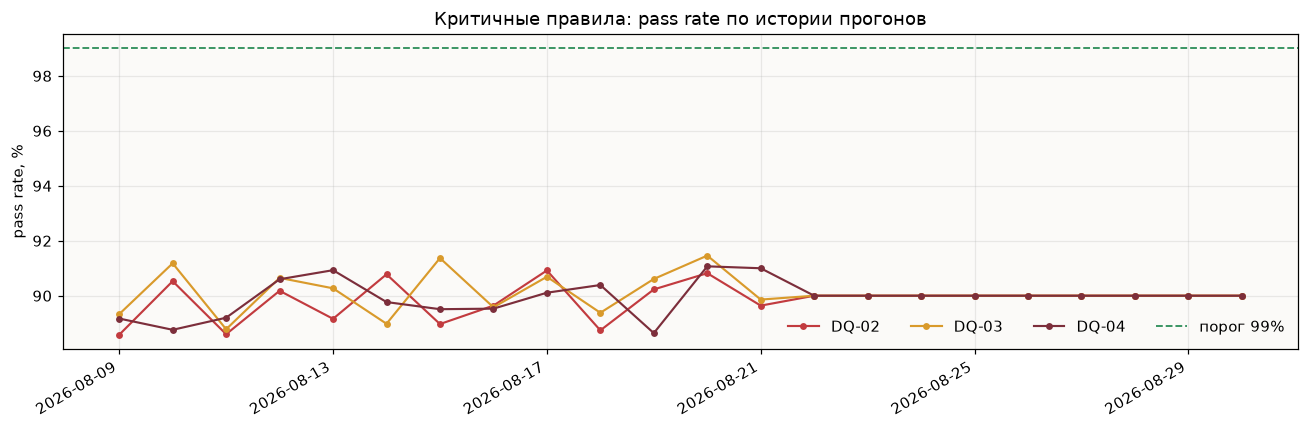

In [20]:
trend = q("""
    SELECT r.run_started_at::date AS day, c.rule_id, c.pass_rate_pct
    FROM public.dq_check_results c
    JOIN public.dq_run_history r USING (run_id)
    WHERE c.rule_id IN ('DQ-02', 'DQ-03', 'DQ-04')
    ORDER BY r.run_started_at
""")
pivot = trend.pivot_table(index="day", columns="rule_id", values="pass_rate_pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 4))
for col, color in zip(pivot.columns, ["#c23b3f", "#d99a2b", "#7c2e3b"]):
    ax.plot(pivot.index, pivot[col], marker="o", ms=3.5, lw=1.4, color=color, label=col)
ax.axhline(99, ls="--", lw=1.2, color="#2f8f5b", label="порог 99%")
ax.set_title("Критичные правила: pass rate по истории прогонов", fontsize=12)
ax.set_ylabel("pass rate, %")
ax.grid(alpha=.25)
ax.legend(frameon=False, ncol=4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Итоги профилирования

**Классификация выявленных проблем**

| # | Проблема | Класс DQ-проблемы | Масштаб | Критичность |
|---|---|---|---|---|
| 1 | Принятые операции не доехали до витрины | Полнота (completeness) — потеря записей при загрузке | 10% потока | Высокая: слепая зона контроля, ложные претензии к организациям |
| 2 | `org_id` теряет ведущий ноль | Точность / формат — числовое приведение при **ручной довставке** данных | 10% витрины | Высокая: возникла при попытке починить проблему 1 |
| 2а | Баланс перемещений не сходится | Согласованность — следствие проблем 1 и 2 | 35% пар | Высокая: недостоверная картина товародвижения |
| 3 | Ни одна партия не дошла до витрины полностью | Полнота (следствие проблемы 1) | все 10 000 партий | Высокая: прослеживаемость партии не восстанавливается по витрине |
| 4 | `bottling_date`, `wbpid` не заполняются ни разу | Полнота на уровне схемы | 100% потока | Средняя: теряется прослеживаемость партии |
| 5 | Журнал изменений витрины не ведётся | Прослеживаемость (traceability) | — | Средняя: блокирует расследование, критично для юридически значимых данных |

Дубликатов, «сирот», аномалий в знаке количества, форматах Форм А/Б и датах не обнаружено —
контрольные проверки чистые.

**Что из этого следует для следующих шагов**

1. Правила обязаны включать **сверку с эталоном**, а не только внутренние проверки витрины
   (Шаг 3 — DQ-02, DQ-04, DQ-11).
2. Правила по справкам должны проверять **иерархию, а не уникальность** (DQ-12, DQ-13):
   номера справок повторяются по природе документа.
3. Преобразования загрузки нужно закрепить контрактом, отдельно оговорив строковый тип кода
   организации (Шаг 5).
4. Правило-сторож происхождения строк (DQ-11) **не заменяет** проверок по существу данных:
   ручную довставку реальных записей оно пропускает — её ловит баланс перемещения (DQ-14).
5. Нужен журнал изменений витрины: без него нельзя установить автора ручной вставки.
6. Мониторинг должен быть ежедневным: дефект прожил в витрине минимум квартал именно потому,
   что его нечем было заметить (Шаги 4 и 6).

In [21]:
conn.close()
print("Соединение закрыто. Профилирование завершено.")

Соединение закрыто. Профилирование завершено.
